# 6. Topic modeling with MALLET

What is podcasting *about*? Categories give a coarse answer — someone chose
"Society & Culture" from a dropdown once. Topic modeling gives a bottom-up
answer, derived from what people actually say.

This notebook fits an LDA model with **MALLET**, which remains the reference
implementation for Gibbs-sampled LDA and usually gives more coherent topics than
the common Python alternatives. It runs on the JVM, so we drive it through
`little-mallet-wrapper`.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))     # prefer the source tree
sys.path.insert(0, os.path.dirname(os.path.abspath("_viz.py")))

import sporc
if sporc.__version__ < "1.0":
    raise RuntimeError(
        f"This notebook needs sporc >= 1.0 but imported {sporc.__version__} from "
        f"{os.path.dirname(sporc.__file__)}.\n"
        "PyPI's latest release is 0.2.0, which has a different API, so "
        "`pip install sporc` gets you the wrong one. Install this checkout:\n"
        "    pip install -e /path/to/sporc"
    )

from _viz import apply_style, finish, PALETTE, INK, INK_SECONDARY, INK_MUTED
apply_style()
print("sporc", sporc.__version__, "from", os.path.dirname(sporc.__file__))


sporc 1.0.0 from /home/jurgens/projects/sporc/sporc


In [2]:
from sporc import SPORCDataset

# Built by scripts/make_subset.py; see examples/notebooks/README.md.
SUBSET = os.path.abspath("../../subsets/tutorial")
sporc = SPORCDataset(parquet_dir=SUBSET)
print(sporc)


INFO:sporc.dataset:Initializing Parquet backend from /home/jurgens/projects/sporc/subsets/tutorial


INFO:sporc.parquet_backend:Loading indexes from cache /home/jurgens/projects/sporc/subsets/tutorial/metadata/_index_cache.pkl


INFO:sporc.parquet_backend:ParquetBackend loaded from cache in 0.01s  (512 podcasts, 2,428 episodes)


SPORCDataset(parquet, 512 podcasts, 2428 episodes)


## 6.1 Pointing at MALLET

`little_mallet_wrapper` shells out to the `mallet` binary, so it needs the path
and a working Java. Set `MALLET_PATH` below to your install.


In [3]:
import os, shutil, subprocess

CANDIDATES = [
    os.environ.get("MALLET_PATH"),
    "/home/jurgens/projects/police-killings-language/mallet-2.0.8/bin/mallet",
    shutil.which("mallet"),
]
MALLET_PATH = next((p for p in CANDIDATES if p and os.path.exists(p)), None)

if not MALLET_PATH:
    raise SystemExit(
        "MALLET not found. Download it from https://mimno.github.io/Mallet/ "
        "and set MALLET_PATH (or the env var of the same name)."
    )

java = shutil.which("java")
print("mallet :", MALLET_PATH)
print("java   :", java or "NOT FOUND -- mallet needs a JVM")
print(subprocess.run([java, "-version"], capture_output=True, text=True).stderr.splitlines()[0])


mallet : /home/jurgens/projects/police-killings-language/mallet-2.0.8/bin/mallet
java   : /usr/bin/java


openjdk version "11.0.27" 2025-04-15


## 6.2 Choosing the document unit

This is the modelling decision that matters most, and it is easy to make
thoughtlessly.

* **One document = one episode.** Few, long documents. LDA sees a whole
  wide-ranging conversation as one bag of words and returns mush.
* **One document = one turn.** Many, tiny documents. Most turns are a sentence;
  there is no co-occurrence to learn from.
* **One document = a window of turns.** A chunk of conversation that stays on
  roughly one thing. This is what `Episode.sliding_window()` is for.

We use windows. It is also a nice demonstration of the sliding-window API.


In [4]:
import little_mallet_wrapper as lmw
import pandas as pd

import random

# All 2,421 diarized episodes give ~4.1M tokens, which MALLET fits in ~20
# minutes -- too slow to sit and watch. 600 episodes still yields thousands of
# windows and readable topics. Raise it (or set None) for a real run.
N_EPISODES = 600

eps = [e for e in sporc.iterate_episodes() if e.has_turn_data]
print(f"diarized episodes: {len(eps):,}")

if N_EPISODES and len(eps) > N_EPISODES:
    eps.sort(key=lambda e: (e.podcast_title, e.title))
    eps = random.Random(0).sample(eps, N_EPISODES)
    print(f"sampled          : {len(eps):,}")

docs, meta = [], []
for e in eps:
    if e.turn_count < 12:
        continue
    for win in e.sliding_window(window_size=12, overlap=3):
        text = win.get_text()
        if len(text.split()) < 120:      # too short to carry a topic
            continue
        docs.append(text)
        # episode_id, not title: titles repeat (one podcast here has seven
        # episodes called "Daily Encouragement"), so grouping by title would
        # merge distinct episodes. Keep the title alongside for reading.
        meta.append({"episode_id": e.episode_id, "episode": e.title,
                     "podcast_id": e.podcast_id, "podcast": e.podcast_title,
                     "category": e.primary_category,
                     "date": e.episode_date,
                     "start": win.time_range[0]})

print(f"windows (documents): {len(docs):,}")
print(f"median words/doc   : {int(pd.Series([len(d.split()) for d in docs]).median())}"
      if docs else "")


INFO:sporc.parquet_backend:Loading episode DataFrame from feather cache


INFO:sporc.parquet_backend:Loading podcast DataFrame from feather cache


diarized episodes: 2,421
sampled          : 600


windows (documents): 7,611


median words/doc   : 256


In [5]:
# lmw's default processing lowercases, strips punctuation and short words.
# Podcast-specific stopwords matter: without them every topic is "like/know/yeah".
EXTRA_STOP = {
    "like", "know", "yeah", "just", "really", "think", "going", "right",
    "gonna", "okay", "kind", "sort", "actually", "want", "said", "say",
    "thing", "things", "people", "time", "lot", "way", "good", "little",
    "podcast", "episode", "welcome", "today", "talk", "talking", "guys",
    "come", "look", "make", "need", "let", "does", "did", "got", "get",
}

processed = [lmw.process_string(d, numbers="remove") for d in docs]
processed = [" ".join(w for w in d.split() if w not in EXTRA_STOP) for d in processed]
processed = [d for d in processed if len(d.split()) >= 60]

print(f"documents after cleaning: {len(processed):,}")
print(f"\nexample:\n  {processed[0][:220]}...")


documents after cleaning: 5,406

example:
  everyone phil matea feliciano school business topic timely listening business edge topic colleges reopen guest speaker david axelrod department economics professor feliciano school business axelrod thank axel rod taped s...


## 6.3 Fitting

`train_topic_model` writes MALLET's inputs to a directory, shells out, and reads
the results back. On a few thousand documents this takes a minute or two.


In [6]:
import tempfile, os

NUM_TOPICS = 15
outdir = tempfile.mkdtemp(prefix="sporc_lda_")
print("working dir:", outdir)

# Plain strings, not pathlib.Path: little_mallet_wrapper builds its shell
# command by string concatenation and raises TypeError on a PosixPath.
path_to_training_data       = os.path.join(outdir, "training.txt")
path_to_formatted_training  = os.path.join(outdir, "mallet.training")
path_to_model               = os.path.join(outdir, f"mallet.model.{NUM_TOPICS}")
path_to_topic_keys          = os.path.join(outdir, f"mallet.topic_keys.{NUM_TOPICS}")
path_to_topic_distributions = os.path.join(outdir, f"mallet.topic_distributions.{NUM_TOPICS}")
path_to_word_weights        = os.path.join(outdir, f"mallet.word_weights.{NUM_TOPICS}")
path_to_diagnostics         = os.path.join(outdir, f"mallet.diagnostics.{NUM_TOPICS}.xml")

lmw.import_data(MALLET_PATH, path_to_training_data, path_to_formatted_training,
                processed)
# train_topic_model's signature varies across little-mallet-wrapper releases:
# word_weights/diagnostics are required positionally here, and num_topics is
# positional too. Check inspect.signature(lmw.train_topic_model) if this raises.
lmw.train_topic_model(MALLET_PATH, path_to_formatted_training, path_to_model,
                      path_to_topic_keys, path_to_topic_distributions,
                      path_to_word_weights, path_to_diagnostics,
                      NUM_TOPICS)

topics = lmw.load_topic_keys(path_to_topic_keys)
dists = lmw.load_topic_distributions(path_to_topic_distributions)
print(f"\nfitted {len(topics)} topics over {len(dists)} documents")


working dir: /tmp/sporc_lda_pryuod9w
Importing data...


Complete
Training topic model...


Mallet LDA: 15 topics, 4 topic bits, 1111 topic mask


Data loaded.


max tokens: 9910
total tokens: 975659


...

[beta: 0.03468] 
<980> LL/token: -8.55705


[beta: 0.03464] 
<990> LL/token: -8.55469



0	0.51039	would one mean didn man well went back never day even see stuff could guy something years still remember thought 
1	0.05469	government well world one also war would black states china political book american new crisis trump mean media united british 
2	0.02677	one book world universe particles would sense could well even quantum life thinking different physics entropy something feel theory thought 
3	0.05583	business sales company customer well companies customers clients marketing product one technology back team looking job every next see culture 
4	0.02271	week one mean see lists list two next saw would banned play maybe could ban definitely league five something fire 
5	0.1178	one movie show music love yes see film movies first would great watch man well save song fucking character back 
6	0.09665	health police covid black see also care ways patients change public disease may community well state seen white country one 
7	0.03539	great back sports see hockey well wester

[beta: 0.03452] 
<1000> LL/token: -8.55491

Total time: 5 minutes 16 seconds


Complete

fitted 15 topics over 5406 documents


In [7]:
for i, words in enumerate(topics):
    print(f"topic {i:2d}: {' '.join(words[:10])}")


topic  0: would one mean didn man well went back day never
topic  1: well government world one also war black would china states
topic  2: one world book universe would particles sense could even quantum
topic  3: business sales company customer companies well customers clients marketing team
topic  4: week one mean see lists list two next would banned
topic  5: one movie music show yes love see first film movies
topic  6: health police covid see also black care patients ways change
topic  7: great back sports see well western hockey cigar one year
topic  8: game team players play year one back player golf see
topic  9: well show book thank great work also new love one
topic 10: one something would well mean different work much even see
topic 11: street office food elizabeth eat one eating wine back foods
topic 12: god love word would church jesus lord children one life
topic 13: see game stars games water well new life body one
topic 14: money business one well property real pay back 

## 6.4 Naming the topics

Top words are a prompt, not a label. Read them, read a couple of the documents
that load highest, and name the topic yourself. Automatic labels are how topic
models get over-interpreted.


In [8]:
import numpy as np

D = np.array(dists)
print("Highest-loading document for a few topics:\n")
for t in range(min(4, NUM_TOPICS)):
    j = int(D[:, t].argmax())
    print(f"topic {t} ({' '.join(topics[t][:6])})")
    print(f"   {meta[j]['podcast'][:44]!r} — {meta[j]['category']}")
    print(f"   {processed[j][:170]}...\n")


Highest-loading document for a few topics:

topic 0 (would one mean didn man well)
   'Beyond Fitness with Mel & Bre' — health
   dogs found something weird brass back cat something dogs past brought back condoms stuff weird ass stuff never dildos though never dildo always hear dog find one find fin...

topic 1 (well government world one also war)
   'The Billy Madison Show Podcast' — comedy
   validated cornwallis every british officers mind win crush every opposition pops accomplishing mission accomplishing strategic intent locals see happening loyalists suppo...

topic 2 (one world book universe would particles)
   'The Billy Madison Show Podcast' — comedy
   able stand walk around planet earth feel connection long lineage comfort didn words meant didn particular prayer words articulating ancient tongue rather wanted feel conn...

topic 3 (business sales company customer companies well)
   'The Billy Madison Show Podcast' — comedy
   piece technology piece technology piece technolog

## 6.5 Topic prevalence by category

Do the bottom-up topics line up with the top-down categories? Where they diverge
is usually the interesting part.


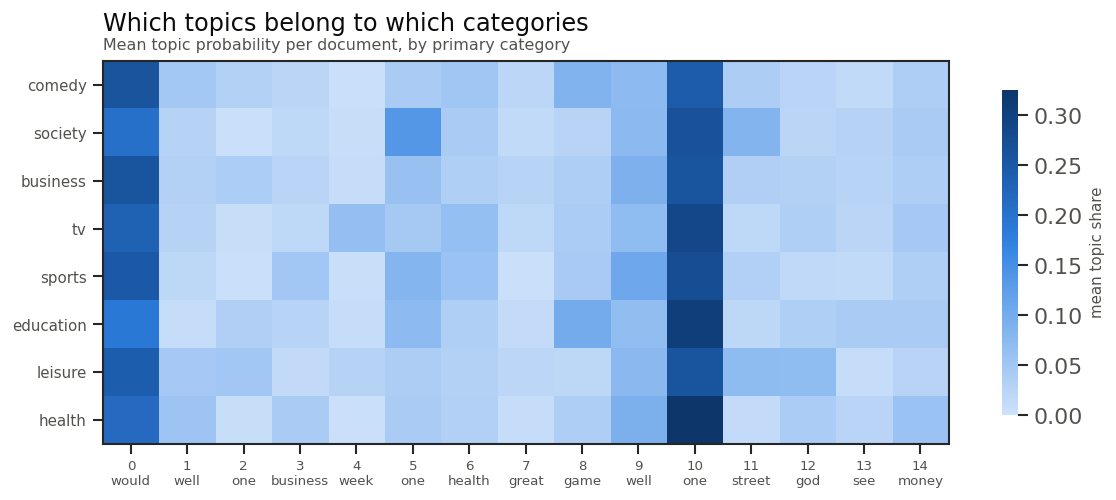

In [9]:
import matplotlib.pyplot as plt
from _viz import sequential_cmap

m = pd.DataFrame(meta[:len(D)])
m = m.assign(**{f"t{i}": D[:, i] for i in range(NUM_TOPICS)})

top_cats = m.category.value_counts().head(8).index.tolist()
mat = (m[m.category.isin(top_cats)]
         .groupby("category")[[f"t{i}" for i in range(NUM_TOPICS)]].mean()
         .loc[top_cats])

fig, ax = plt.subplots(figsize=(10, 4.4))
im = ax.imshow(mat.values, aspect="auto", cmap=sequential_cmap(), vmin=0)
ax.set_xticks(range(NUM_TOPICS))
ax.set_xticklabels([f"{i}\n{topics[i][0][:9]}" for i in range(NUM_TOPICS)],
                   fontsize=8)
ax.set_yticks(range(len(mat)))
ax.set_yticklabels(mat.index, fontsize=9)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.85)
cb.set_label("mean topic share", fontsize=9, color=INK_SECONDARY)
cb.outline.set_visible(False)
finish(ax, title="Which topics belong to which categories",
       subtitle="Mean topic probability per document, by primary category")
plt.show()


In [10]:
# The most category-distinctive topic: highest share relative to its own mean.
rel = mat / mat.mean(axis=0)
for cat in mat.index:
    t = int(rel.loc[cat].values.argmax())
    print(f"  {cat:26s} -> topic {t:2d}  ({' '.join(topics[t][:6])})")


  comedy                     -> topic  8  (game team players play year one)
  society                    -> topic 11  (street office food elizabeth eat one)
  business                   -> topic  2  (one world book universe would particles)
  tv                         -> topic  4  (week one mean see lists list)
  sports                     -> topic  3  (business sales company customer companies well)
  education                  -> topic  8  (game team players play year one)
  leisure                    -> topic  2  (one world book universe would particles)
  health                     -> topic  1  (well government world one also war)


## 6.6 Caveats

* **k is a choice, not a finding.** 15 topics because we said 15. Fit several
  values and look at them; there is no "correct" k, and coherence metrics only
  narrow the field.
* **Stopwords shape the result.** The `EXTRA_STOP` list above is doing real work:
  without it, conversational filler dominates every topic. That list is a
  researcher decision and belongs in your write-up.
* **Windows overlap.** `overlap=3` means adjacent documents share turns, so
  documents are not independent. Fine for description, wrong for anything
  inferential.
* **Ads.** Podcast transcripts are full of read advertising, which forms tight,
  high-coherence topics that are about the ad market rather than the show.
* **Two months, 33% coverage.** As everywhere in SPoRC.
